In [1]:
# https://archive.ics.uci.edu/dataset/53/iris
# Iris
# iris.data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.utils import resample

In [3]:
iris = load_iris()
X = iris.data
y = iris.target

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_augmented, y_augmented = resample(X_pca, y, n_samples=300, random_state=42, stratify=y)

In [5]:
X = torch.autograd.Variable(torch.FloatTensor(X_augmented))
y = torch.autograd.Variable(torch.LongTensor(y_augmented.astype(np.int64)))
print(X.data.shape, y.data.shape)

torch.Size([300, 2]) torch.Size([300])


In [6]:
N, D_in, H, D_out = 64, 2, 100, 3

In [12]:
two_layer_net = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

In [13]:
loss_fn = torch.nn.CrossEntropyLoss(size_average=False)
learning_rate = 1e-4
optimizer = torch.optim.SGD(two_layer_net.parameters(), lr=learning_rate)

C:\Users\dsoko\anaconda3\Lib\site-packages\torch\nn\modules\loss.py:44: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  self.reduction: str = _Reduction.legacy_get_string(size_average, reduce)


In [14]:
for t in range(500):
    y_pred = two_layer_net(X)
    loss = loss_fn(y_pred, y)
    print('{} {}'.format(t, loss.data))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

0 324.60687255859375
1 273.8450622558594
2 240.7737579345703
3 218.6137237548828
4 203.00393676757812
5 191.41519165039062
6 182.40347290039062
7 175.12269592285156
8 169.05760192871094
9 163.88072204589844
10 159.37567138671875
11 155.39395141601562
12 151.82998657226562
13 148.60643005371094
14 145.66519165039062
15 142.9617462158203
16 140.46128845214844
17 138.13609313964844
18 135.96372985839844
19 133.9258270263672
20 132.0071258544922
21 130.1949005126953
22 128.47836303710938
23 126.8482666015625
24 125.29669952392578
25 123.81678009033203
26 122.40267944335938
27 121.04920196533203
28 119.75152587890625
29 118.50547790527344
30 117.3074722290039
31 116.15410614013672
32 115.0423583984375
33 113.96946716308594
34 112.93305969238281
35 111.93087005615234
36 110.96088409423828
37 110.02120971679688
38 109.11015319824219
39 108.22613525390625
40 107.36782836914062
41 106.5342025756836
42 105.72379302978516
43 104.93525695800781
44 104.16756439208984
45 103.41966247558594
46 102.69

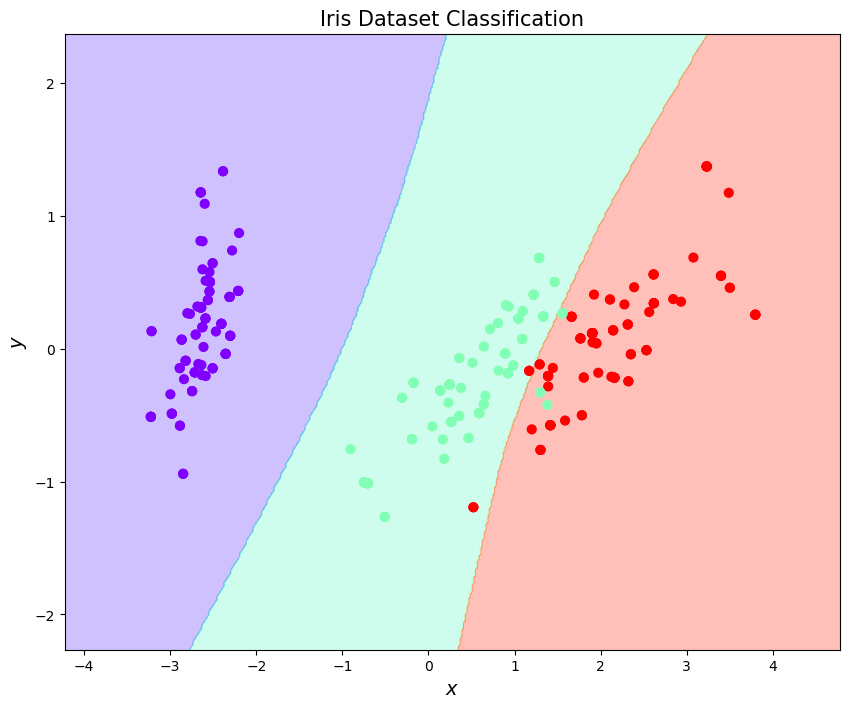

In [15]:
X = X.data.numpy()
y = y.data.numpy()
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
Z = two_layer_net(torch.autograd.Variable(grid_tensor))
Z = Z.data.numpy()
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.rainbow, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.rainbow)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title('Iris Dataset Classification', fontsize=15)
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.show()